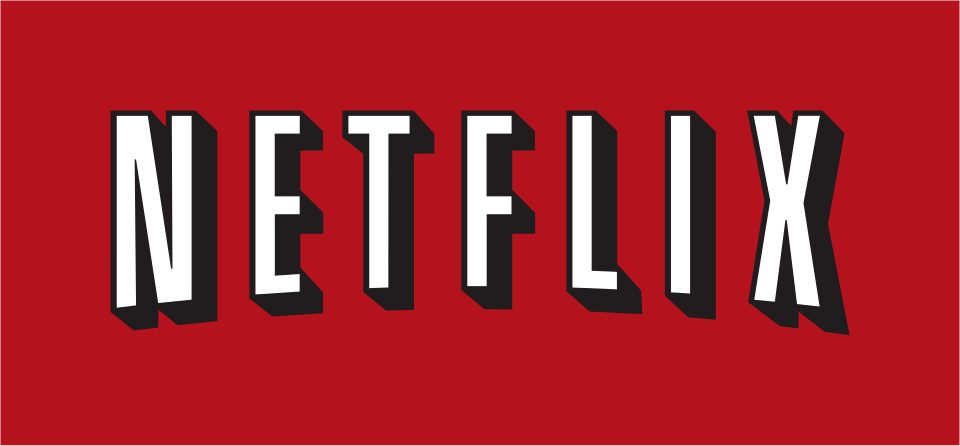

# ETL & EDA

## ETL - Extrair, Transformar e Carregar

In [2]:
'''
Verificar os arquivos:
- src/extract.py
- src/cleaning.py
- src/feature_engineering.py
- src/load.py
'''

import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent
sys.path.append(str(PROJECT_ROOT))

from src.load import save_processed_data

save_processed_data('../data/raw/netflix_titles.csv')

Arquivos salvos com sucesso!


## Análise Exploratória de Dados (EDA)

### Importação das bibliotecas e Leitura do dataset

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import squarify
import seaborn as sns
import plotly.express as px 
import warnings

# Exibir todas as linhas
pd.set_option('display.max_rows', None)
# Exibir todas as colunas
pd.set_option('display.max_columns', None)
warnings.filterwarnings("ignore")
#!pip freeze > requirements.txt

netflix = pd.read_csv('../data/processed/netflix.csv')
netflix_directors = pd.read_csv('../data/processed/netflix_directors.csv')
netflix_cast = pd.read_csv('../data/processed/netflix_cast.csv')

netflix_movies = netflix[netflix['type'] == 'Movie'].reset_index(drop=True).copy()
netflix_tv = netflix[netflix['type'] == 'TV Show'].reset_index(drop=True).copy()

In [4]:
netflix.shape

(8807, 24)

In [5]:
netflix.duplicated().sum()

np.int64(0)

In [6]:
netflix.isnull().sum()

type                 0
title                0
description          0
director             0
n_directors          0
cast                 0
n_cast_members       0
country              0
n_countries          0
main_country         0
continent            0
language             0
release_year         0
release_decade       0
date_added           0
year_added           0
delay_added          0
rating               0
rating_group         0
duration             0
duration_category    0
listed_in            0
n_genres             0
genre                0
dtype: int64

In [7]:
netflix.head()

,type,title,description,director,n_directors,cast,n_cast_members,country,n_countries,main_country,continent,language,release_year,release_decade,date_added,year_added,delay_added,rating,rating_group,duration,duration_category,listed_in,n_genres,genre
0,Movie,Dick Johnson Is Dead,"As her father nears the end of his life, filmm...",Kirsten Johnson,1,Not Informed,0,United States,1,United States,North America,English,2020,2020,2021-09-25,2021,1,PG-13,Teen,90,Feature Film,Documentaries,1,Documentary
1,TV Show,Blood & Water,"After crossing paths at a party, a Cape Town t...",Not Informed,0,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",19,South Africa,1,South Africa,Africa,English,2021,2020,2021-09-24,2021,0,TV-MA,Adult,2,Short Series,"International TV Shows, TV Dramas, TV Mysteries",3,International
2,TV Show,Ganglands,To protect his family from a powerful drug lor...,Julien Leclercq,1,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",9,Unknown,0,Unknown,Unknown,Unknown,2021,2020,2021-09-24,2021,0,TV-MA,Adult,1,Limited Series,"Crime TV Shows, International TV Shows, TV Act...",3,Crime
3,TV Show,Jailbirds New Orleans,"Feuds, flirtations and toilet talk go down amo...",Not Informed,0,Not Informed,0,Unknown,0,Unknown,Unknown,Unknown,2021,2020,2021-09-24,2021,0,TV-MA,Adult,1,Limited Series,"Docuseries, Reality TV",2,Documentary
4,TV Show,Kota Factory,In a city of coaching centers known to train I...,Not Informed,0,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",8,India,1,India,Asia,Hindi,2021,2020,2021-09-24,2021,0,TV-MA,Adult,2,Short Series,"International TV Shows, Romantic TV Shows, TV ...",3,International


### Proporção de filmes e séries no catálogo da Netflix

In [8]:
netflix_type = netflix['type'].value_counts().reset_index()
netflix_type['proportion'] = (netflix_type['count'] / netflix_type['count'].sum() * 100).round(2)
netflix_type


,type,count,proportion
0,Movie,6131,69.62
1,TV Show,2676,30.38


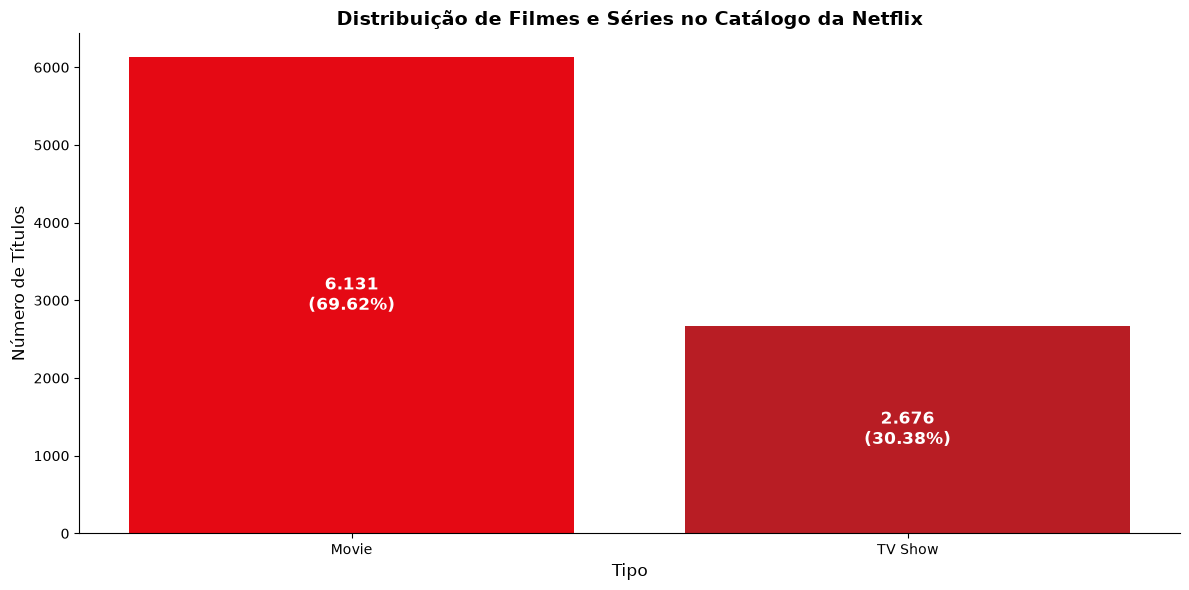

In [9]:
fig, ax = plt.subplots(figsize=(12, 6))

bars = ax.bar(
    netflix_type['type'],
    netflix_type['count'],
    color=['#E50914', '#B81D24']
)

for bar, count, prop in zip(bars, netflix_type['count'], netflix_type['proportion']):
    ax.text(
        bar.get_x() + bar.get_width()/2,   # posição horizontal central
        bar.get_height()/2,                # posição vertical central
        f'{count:,}\n({prop:.2f}%)'.replace(',', '.'),  # quantidade + porcentagem
        ha='center',
        va='center',
        color='white',
        fontweight='bold',
        fontsize=12
    )

ax.set_title('Distribuição de Filmes e Séries no Catálogo da Netflix',fontsize=14,fontweight='bold')
ax.set_ylabel('Número de Títulos', fontsize=12)
ax.set_xlabel('Tipo', fontsize=12)

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()


## Filmes

### Quantidades de Produções de Filmes por País

In [10]:
movies_country = netflix_movies['main_country'].value_counts().reset_index()
movies_country['proportion'] = (movies_country['count'] / netflix_type['count'].sum() * 100).round(2)
movies_country.head(20)

,main_country,count,proportion
0,United States,2364,26.84
1,India,927,10.53
2,Unknown,440,5.00
3,United Kingdom,382,4.34
4,Canada,187,2.12
5,France,149,1.69
6,Spain,129,1.46
7,Egypt,98,1.11
8,Nigeria,87,0.99
9,Mexico,86,0.98


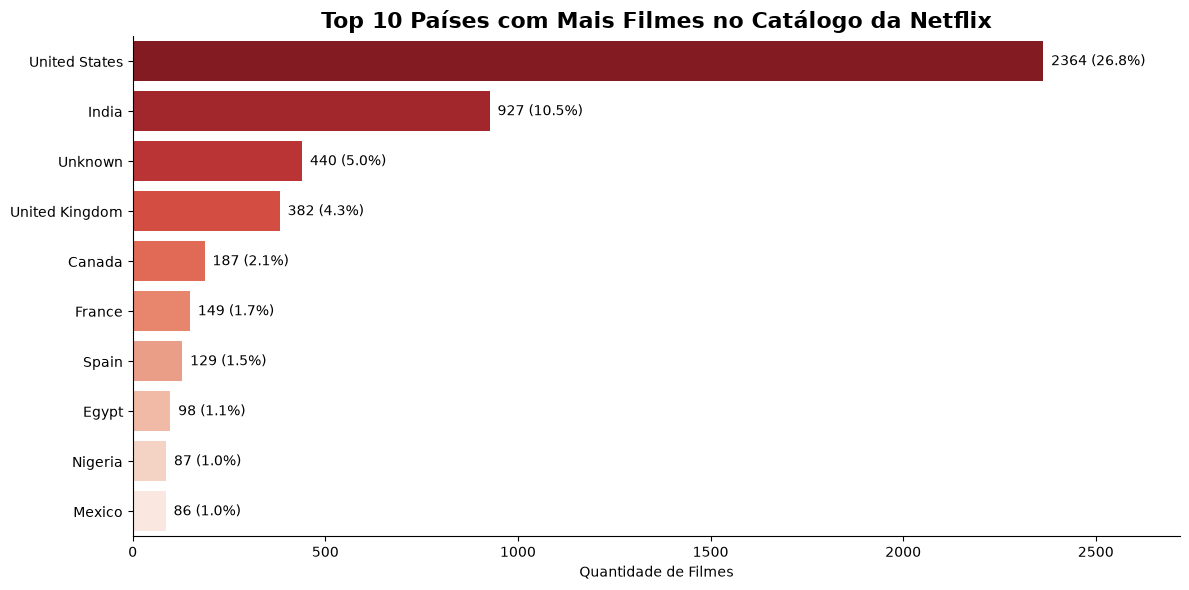

In [11]:
plt.figure(figsize=(12, 6))

top10 = movies_country.head(10)

ax = sns.barplot(data=top10, x='count', y='main_country', palette='Reds_r')

for i, (_, row) in enumerate(top10.iterrows()):
    ax.text(
        row['count'] + 20,
        i,
        f"{row['count']} ({row['proportion']:.1f}%)",
        va='center',
        fontsize=10
    )

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.title('Top 10 Países com Mais Filmes no Catálogo da Netflix',fontsize=16,fontweight='bold')
plt.xlabel('Quantidade de Filmes')
plt.ylabel('')
plt.xlim(0, top10['count'].max() * 1.15)
plt.tight_layout()
plt.show()

### Quantidades de Produções de Filmes por Continente

In [12]:
movies_continent = netflix_movies['continent'].value_counts().reset_index()
movies_continent['proportion'] = (movies_continent['count'] / netflix_type['count'].sum() * 100).round(2)
movies_continent

,continent,count,proportion
0,North America,2637,29.94
1,Asia,1530,17.37
2,Europe,1046,11.88
3,Unknown,446,5.06
4,Africa,232,2.63
5,South America,162,1.84
6,Oceania,76,0.86
7,Central America,2,0.02


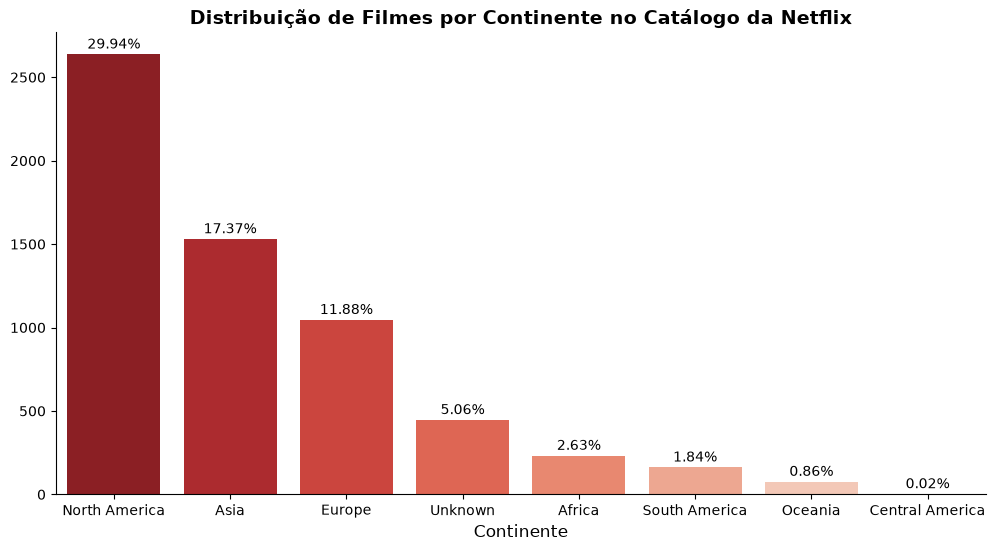

In [13]:
plt.figure(figsize=(12, 6))
ax = sns.barplot(
    data=movies_continent,
    x='continent',
    y='count',
    palette='Reds_r'
)

# Loop para adicionar textos acima das barras
for bar, prop in zip(ax.patches, movies_continent['proportion']):
    ax.text(
        bar.get_x() + bar.get_width()/2,   # centro da barra no eixo X
        bar.get_height() + 15,             # um pouco acima da barra
        f'{prop:.2f}%',                    # texto da porcentagem
        ha='center',
        va='bottom',
        color='black',
        fontsize=10
    )

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.title('Distribuição de Filmes por Continente no Catálogo da Netflix', fontsize=14, fontweight='bold')
plt.xlabel('Continente', fontsize=12)
plt.ylabel('')
plt.show()


### Quantidades de Produções de Filmes por Língua

In [14]:
movies_language = netflix_movies['language'].value_counts().reset_index()
movies_language['proportion'] = (movies_language['count'] / netflix_type['count'].sum() * 100).round(2)
movies_language.head(20)

,language,count,proportion
0,English,3174,36.04
1,Hindi,927,10.53
2,Unknown,446,5.06
3,Spanish,322,3.66
4,French,160,1.82
5,Arabic,149,1.69
6,German,93,1.06
7,Japanese,85,0.97
8,Indonesian,83,0.94
9,Turkish,81,0.92


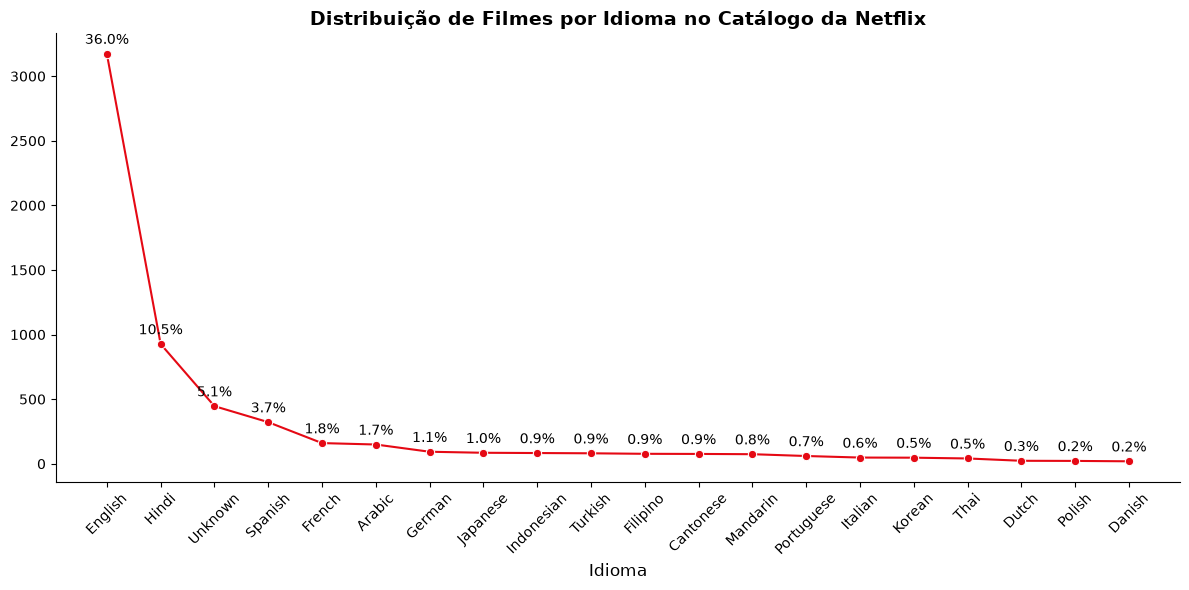

In [15]:
plt.figure(figsize=(12, 6))
ax = sns.lineplot(
    data=movies_language.head(20),
    x='language',
    y='count',
    marker='o',
    color='#E50914'
)

# Adicionando porcentagem acima dos pontos
for x, y, prop in zip(movies_language['language'].head(20),
                      movies_language['count'].head(20),
                      movies_language['proportion'].head(20)):
    ax.text(
        x, y + 50, f'{prop:.1f}%',
        ha='center',
        va='bottom',
        fontsize=10,
        color='black'
    )

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.title('Distribuição de Filmes por Idioma no Catálogo da Netflix', fontsize=14, fontweight='bold')
plt.xlabel('Idioma', fontsize=12)
plt.ylabel('')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### Quantidades de Produções de Filmes por Gênero

In [16]:
movies_genre = netflix_movies['genre'].value_counts().reset_index()
movies_genre['proportion'] = (movies_genre['count'] / netflix_type['count'].sum() * 100).round(2)
movies_genre

,genre,count,proportion
0,Drama,1600,18.17
1,Comedy,1544,17.53
2,Action & Adventure,859,9.75
3,Documentary,829,9.41
4,Family,605,6.87
5,Horror,275,3.12
6,Other,170,1.93
7,International,128,1.45
8,Crime,65,0.74
9,Anime,21,0.24


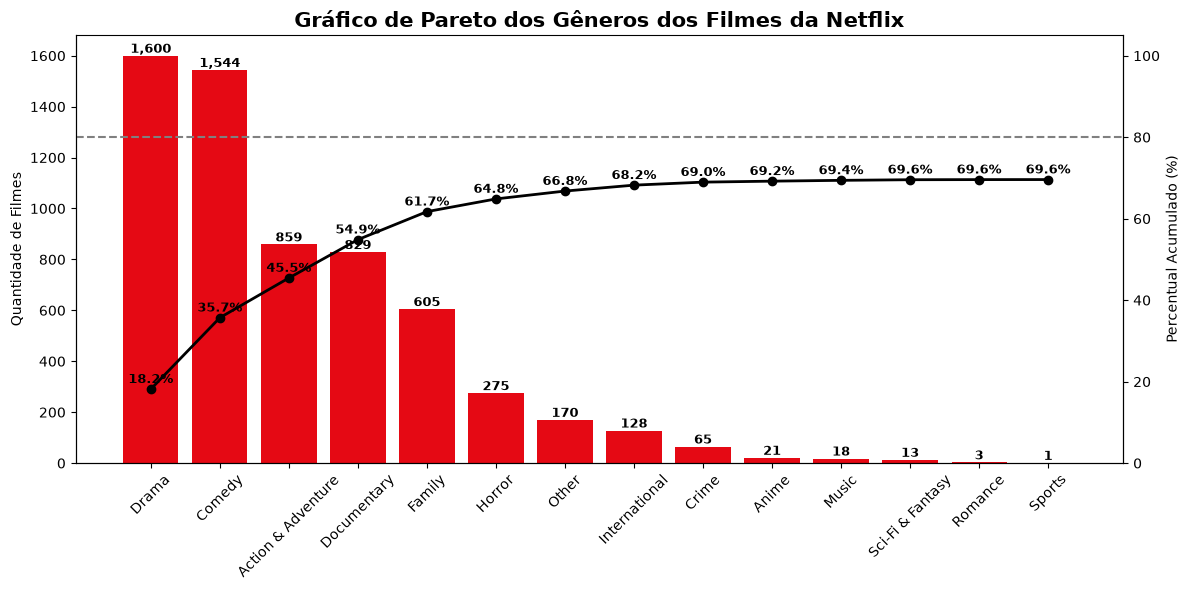

In [17]:
fig, ax1 = plt.subplots(figsize=(12, 6))

bars = ax1.bar(movies_genre['genre'], movies_genre['count'], color='#E50914')

for bar in bars:
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height(), f'{int(bar.get_height()):,}', ha='center', va='bottom', fontsize=9, fontweight='bold')

ax1.set_ylabel('Quantidade de Filmes')
ax1.tick_params(axis='x', rotation=45)
ax1.spines['top'].set_visible(False)

ax2 = ax1.twinx()

ax2.plot(
    movies_genre['genre'],
    movies_genre['proportion'].cumsum(),
    color='black',
    marker='o',
    linewidth=2
)

for i, value in enumerate(movies_genre['proportion'].cumsum()):
    ax2.text(i, value + 1.5, f'{value:.1f}%', ha='center', fontsize=9, fontweight='bold')

ax2.axhline(y=80, color='gray', linestyle='--', linewidth=1.5)
ax2.set_ylabel('Percentual Acumulado (%)')
ax2.set_ylim(0, 105)

plt.title('Gráfico de Pareto dos Gêneros dos Filmes da Netflix', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

### Quantidades de Produções de Filmes por Classificação Etária

In [18]:
movies_rating = netflix_movies['rating_group'].value_counts().reset_index()
movies_rating['proportion'] = (movies_rating['count'] / netflix_type['count'].sum() * 100).round(2)
movies_rating

,rating_group,count,proportion
0,Adult,2862,32.50
1,Teen,2457,27.90
2,Family,413,4.69
3,Kids,316,3.59
4,Unknown,83,0.94


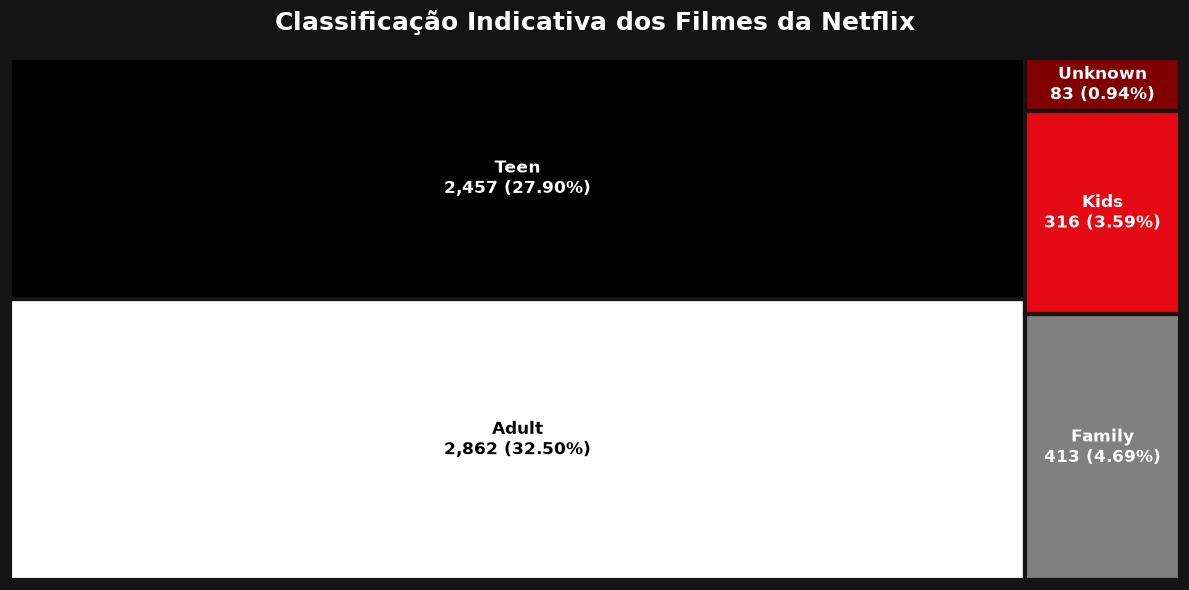

In [19]:
labels = [f"{row['rating_group']}\n{row['count']:,} ({row['proportion']:.2f}%)"
          for _, row in movies_rating.iterrows()]

sizes = movies_rating['count']

# Paleta: branco, preto, cinza, vermelho e bordô
colors = ['#FFFFFF', '#000000', '#808080', '#E50914', '#800000']

# Cor do texto para cada retângulo
text_colors = ['black' if color == '#FFFFFF' else 'white' for color in colors]

plt.figure(figsize=(12, 6), facecolor='#141414')
ax = plt.gca()
ax.set_facecolor('#141414')

# Desenha os retângulos
squarify.plot(sizes=sizes,color=colors, alpha=1,bar_kwargs={'edgecolor': '#141414','linewidth': 3})

# Adiciona os textos manualmente
rects = squarify.normalize_sizes(sizes, 100, 100)
rects = squarify.squarify(rects, 0, 0, 100, 100)

for rect, label, text_color in zip(rects, labels, text_colors):
    plt.text(
        rect['x'] + rect['dx'] / 2,
        rect['y'] + rect['dy'] / 2,
        label,ha='center',va='center',fontsize=12,fontweight='bold',color=text_color)

plt.title( 'Classificação Indicativa dos Filmes da Netflix',fontsize=18,fontweight='bold',color='white', pad=20)
plt.axis('off')
plt.tight_layout()
plt.show()

### Distribuição da Duração dos Filmes em Minutos

In [20]:
netflix_movies['duration'].describe()

count    6131.000000
mean       99.564998
std        28.289504
min         3.000000
25%        87.000000
50%        98.000000
75%       114.000000
max       312.000000
Name: duration, dtype: float64

In [21]:
Q1 = netflix_movies['duration'].quantile(0.25)
Q3 = netflix_movies['duration'].quantile(0.75)

IQR = Q3 - Q1

limite_inferior = Q1 - 1.5 * IQR
limite_superior = Q3 + 1.5 * IQR

# Outliers abaixo do limite inferior
outliers_abaixo = netflix_movies[netflix_movies['duration'] < limite_inferior]

# Outliers acima do limite superior
outliers_acima = netflix_movies[netflix_movies['duration'] > limite_superior]

# Quantidades
qtd_abaixo = len(outliers_abaixo)
qtd_acima = len(outliers_acima)
qtd_total = qtd_abaixo + qtd_acima

print(f'Limite inferior: {limite_inferior:.0f} minutos')
print(f'Limite superior: {limite_superior:.0f} minutos')
print('-' * 40)
print(f'Outliers abaixo do limite: {qtd_abaixo}')
print(f'Outliers acima do limite: {qtd_acima}')
print(f'Total de outliers: {qtd_total}')

Limite inferior: 46 minutos
Limite superior: 154 minutos
----------------------------------------
Outliers abaixo do limite: 249
Outliers acima do limite: 201
Total de outliers: 450


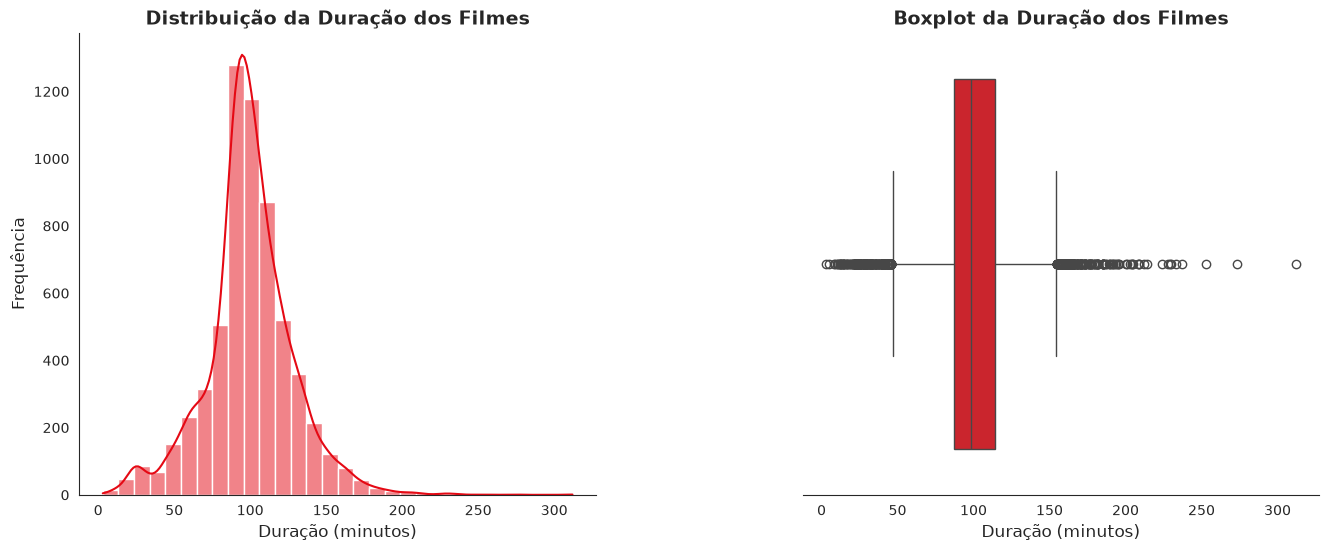

In [22]:
import matplotlib.pyplot as plt
import seaborn as sns

# Tirando o quadriculado
sns.set_style("white")

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Histograma
sns.histplot(netflix_movies['duration'], bins=30, kde=True, color='#E50914', ax=axes[0])
axes[0].set_title('Distribuição da Duração dos Filmes', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Duração (minutos)', fontsize=12)
axes[0].set_ylabel('Frequência', fontsize=12)
axes[0].spines['top'].set_visible(False)
axes[0].spines['right'].set_visible(False)

# Boxplot
sns.boxplot(x=netflix_movies['duration'], color='#E50914', ax=axes[1])
axes[1].set_title('Boxplot da Duração dos Filmes', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Duração (minutos)', fontsize=12)
axes[1].spines['top'].set_visible(False)
axes[1].spines['left'].set_visible(False)
axes[1].spines['right'].set_visible(False)

# Espaçamento entre os gráficos
plt.subplots_adjust(wspace=0.4)

plt.show()


### Quantidades de Produções de Filmes por Duração (curta, média ou longa)

In [23]:
'''
- Short Film: até 40 min
- Medium-length Film: 41 a 70 min
- Feature Film: acima de 70 min
'''

movies_duration = netflix_movies['duration_category'].value_counts().reset_index()
movies_duration['proportion'] = (movies_duration['count'] / netflix_movies['duration_category'].count() * 100).round(2)
movies_duration

,duration_category,count,proportion
0,Feature Film,5378,87.72
1,Medium-length Film,570,9.30
2,Short Film,183,2.98


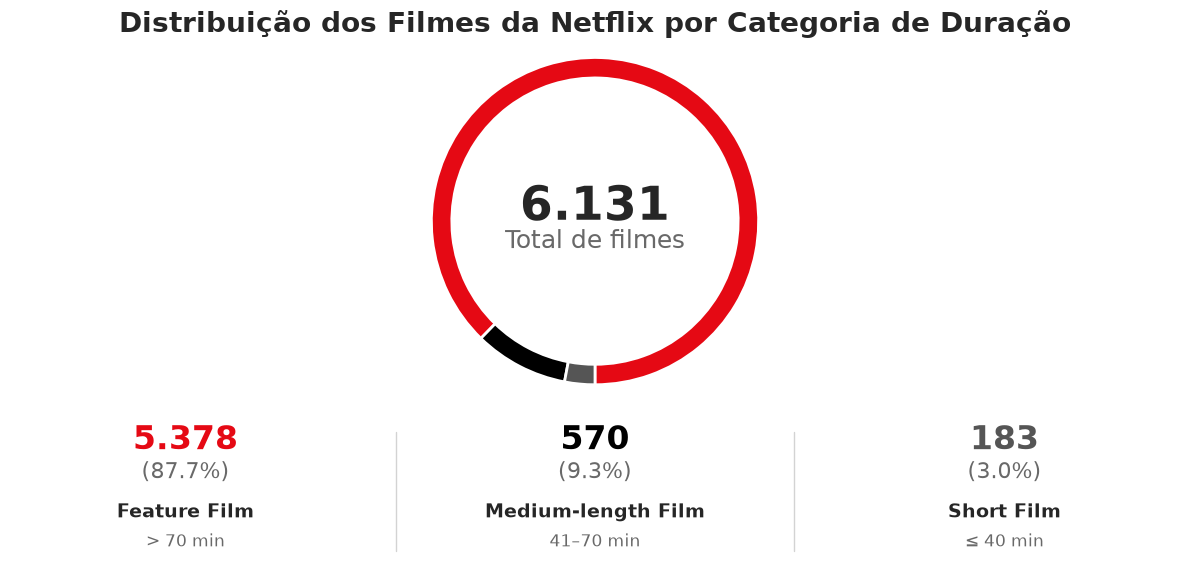

In [24]:
# Dados
labels = ['Feature Film', 'Medium-length Film', 'Short Film']
subtitles = ['> 70 min', '41–70 min', '≤ 40 min']
sizes = movies_duration['count']
colors = ['#E50914', '#000000', '#555555']

# Figura (2/3 gráfico e 1/3 legendas)
fig = plt.figure(figsize=(12, 6))
gs = fig.add_gridspec(nrows=2, ncols=1, height_ratios=[2, 1])

ax_donut = fig.add_subplot(gs[0])
ax_legend = fig.add_subplot(gs[1])

# Gráfico de rosca
wedges, _ = ax_donut.pie(
    sizes,
    startangle=270,
    colors=colors,
    radius=1.2,
    wedgeprops={'width': 0.15, 'edgecolor': 'white', 'linewidth': 2}
)

total = sizes.sum()

# Texto central
ax_donut.text(0, 0.10, f'{total:,}'.replace(',', '.'), ha='center', va='center', fontsize=34, fontweight='bold')
ax_donut.text(0, -0.15, 'Total de filmes', ha='center', va='center', fontsize=18, color='dimgray')

ax_donut.set_aspect('equal')
ax_donut.axis('off')

# Legendas
ax_legend.axis('off')
x_positions = [0.15, 0.50, 0.85]

for x, label, subtitle, value, color in zip(x_positions, labels, subtitles, sizes, colors):
    pct = value / total * 100

    ax_legend.text(x, 0.75, f'{value:,}'.replace(',', '.'), transform=ax_legend.transAxes, ha='center', fontsize=24, fontweight='bold', color=color)
    ax_legend.text(x, 0.58, f'({pct:.1f}%)', transform=ax_legend.transAxes, ha='center', fontsize=16, color='dimgray')
    ax_legend.text(x, 0.35, label, transform=ax_legend.transAxes, ha='center', fontsize=14, fontweight='bold')
    ax_legend.text(x, 0.18, subtitle, transform=ax_legend.transAxes, ha='center', fontsize=12, color='dimgray')

# Linhas divisórias
for x in [0.33, 0.67]:
    ax_legend.plot([x, x], [0.15, 0.85], transform=ax_legend.transAxes, color='lightgray', linewidth=1)

# Título
fig.suptitle('Distribuição dos Filmes da Netflix por Categoria de Duração', fontsize=20, fontweight='bold', y=0.97)

plt.tight_layout()
plt.show()

## Programas de Televisão